# Notebook 3 - Noise, Monte Carlo, and the Threshold

*Part of **QEC Explorer**. Back in **Notebook 1** we opened with a plot - logical error rate dropping as code distance grows - and said "the full derivation comes later." This is later. We're going to **earn that plot** two ways: first with a hand-built Monte Carlo over the decoders you wrote in Notebook 2, then with the real industry pipeline - **Stim + Sinter + PyMatching** - the exact toolchain Google and IBM use to measure thresholds.*

The plan:
1. Re-load the verified surface code **and the three decoders from Notebook 2** - kept verbatim so nothing drifts.
2. Build two **noise models** (depolarizing, biased) - the same two as the **Module 3** web tool.
3. Run a hand **Monte Carlo** sweep and look *honestly* at what it shows at small distance.
4. Then run the **professional Stim + Sinter** sweep - the real circuit-level experiment - and watch a **clean threshold crossing** appear.

> ### Built on Stim + Sinter + PyMatching
> This is a QEC Explorer spin-off notebook. Section 6 runs **[Sinter](https://github.com/quantumlib/Stim/tree/main/glue/sample)** (Google Quantum AI, Apache-2.0), the parallel Monte-Carlo sampler built on **Stim** and **PyMatching**, to measure a threshold the same way a real QEC paper does. Our hand-built sweep teaches the mechanism; Sinter delivers the publication-grade curve.

> ### Same experiment, live
> The **Module 3 - Noise Explorer** runs the hand Monte Carlo in your browser:
> **-> [QEC Explorer - Module 3 (live)](https://qecexplorer.com/noise)**

---
## 1 - Re-load the code and decoders from Notebook 2 (verbatim, no drift)

The cell below is **copied from Notebook 2** so this notebook stands alone: the surface-code build, the residual-based success test, and all three decoders (lookup, MWPM, BP). We install **Stim, Sinter, and PyMatching** here too, for the professional sweep in Section 6.

In [1]:
# Colab / fresh-environment setup. Safe to re-run.
try:
    import stim, sinter, pymatching
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "stim", "sinter", "pymatching"], check=True)
    import stim, sinter, pymatching


import numpy as np
import matplotlib.pyplot as plt
from itertools import product

np.random.seed(0)
plt.rcParams["figure.dpi"] = 110

# ---- from Notebook 1: data qubits, stabilizers, syndrome (ports of lattice-core.js) ----
def build_data_qubits(d):
    return [(r, c) for r in range(d) for c in range(d)]

def build_stabilizers(d):
    stabs = []
    for R in range(-1, d):
        for C in range(-1, d):
            stype = "Z" if (R + C) % 2 == 0 else "X"
            corners = [(R, C), (R, C + 1), (R + 1, C), (R + 1, C + 1)]
            cand = [(rr, cc) for (rr, cc) in corners if 0 <= rr < d and 0 <= cc < d]
            if len(cand) == 0:
                continue
            on_top_bottom = (R == -1 or R == d - 1)
            on_left_right = (C == -1 or C == d - 1)
            if len(cand) == 2:
                if stype == "Z" and not on_left_right: continue
                if stype == "X" and not on_top_bottom: continue
            if len(cand) not in (2, 4):
                continue
            stabs.append({"type": stype, "center": (C + 0.5, R + 0.5), "data": cand})
    return stabs

def compute_syndrome(stabs, errors):
    syn = []
    for s in stabs:
        parity = 0
        for (r, c) in s["data"]:
            e = errors.get((r, c))
            if not e: continue
            if s["type"] == "Z" and e.get("x"): parity ^= 1
            if s["type"] == "X" and e.get("z"): parity ^= 1
        syn.append(parity)
    return syn

def combine_errors(a, b):
    out = {}
    for k in set(a) | set(b):
        ea = a.get(k, {"x": False, "z": False}); eb = b.get(k, {"x": False, "z": False})
        x = bool(ea.get("x")) ^ bool(eb.get("x"))
        z = bool(ea.get("z")) ^ bool(eb.get("z"))
        if x or z:
            out[k] = {"x": x, "z": z}
    return out

def error_weight(errors):
    return sum(1 for k in errors if errors[k].get("x") or errors[k].get("z"))

def diff_keys(a, b):
    out = []
    for k in set(a) | set(b):
        ea = a.get(k, {"x": False, "z": False}); eb = b.get(k, {"x": False, "z": False})
        if bool(ea.get("x")) != bool(eb.get("x")) or bool(ea.get("z")) != bool(eb.get("z")):
            out.append(k)
    return sorted(out)

def logical_status(stabs, errors, d):
    syn = compute_syndrome(stabs, errors)
    if any(syn):
        return {"logical": False, "detectable": True}
    x_col0 = z_row0 = 0
    for r in range(d):
        e = errors.get((r, 0))
        if e and e.get("x"): x_col0 ^= 1
    for c in range(d):
        e = errors.get((0, c))
        if e and e.get("z"): z_row0 ^= 1
    return {"logical": (x_col0 == 1 or z_row0 == 1), "detectable": False}

def evaluate_correction(stabs, original_errors, correction, d):
    residual = combine_errors(original_errors, correction)
    if any(compute_syndrome(stabs, residual)):
        return {"status": "left-codespace", "ok": False, "label": "Did not return to codespace"}
    if logical_status(stabs, residual, d)["logical"]:
        return {"status": "logical-introduced", "ok": False, "label": "Logical error introduced"}
    return {"status": "fixed", "ok": True, "label": "Fixed"}

DETECTOR_TYPE = {"X": "Z", "Z": "X"}

def stabs_of_type(stabs, stype):
    return [(i, s) for i, s in enumerate(stabs) if s["type"] == stype]

def apply_flips(correction, qubit_keys, channel):
    for k in qubit_keys:
        cur = correction.get(k, {"x": False, "z": False}).copy()
        if channel == "X": cur["x"] = not cur["x"]
        else:              cur["z"] = not cur["z"]
        if not cur["x"] and not cur["z"]: correction.pop(k, None)
        else:                              correction[k] = cur

def build_lookup_table(stabs, data, d):
    if d != 3:
        return None
    table = {}
    def consider(errors):
        k = tuple(compute_syndrome(stabs, errors)); w = error_weight(errors)
        prev = table.get(k)
        if prev is None or w < prev["weight"]:
            table[k] = {"weight": w, "correction": dict(errors), "degenerate": False}
        elif w == prev["weight"] and len(diff_keys(prev["correction"], errors)) > 0:
            prev["degenerate"] = True
    paulis = [{"x": True, "z": False}, {"x": False, "z": True}, {"x": True, "z": True}]
    consider({})
    for q in data:
        for p in paulis: consider({q: dict(p)})
    for i in range(len(data)):
        for j in range(i + 1, len(data)):
            for pa in paulis:
                for pb in paulis: consider({data[i]: dict(pa), data[j]: dict(pb)})
    return table

def lookup_decode(stabs, table, errors):
    if table is None:
        return {"available": False, "correction": {}, "degenerate": False}
    hit = table.get(tuple(compute_syndrome(stabs, errors)))
    if hit is None:
        return {"available": True, "correction": {}, "degenerate": False}
    return {"available": True, "correction": dict(hit["correction"]), "degenerate": hit["degenerate"]}

BOUNDARY = "BOUNDARY"

def build_channel_graph(stabs, data, channel):
    det_type = DETECTOR_TYPE[channel]
    dets = stabs_of_type(stabs, det_type); det_idx = [i for (i, s) in dets]
    adj = {BOUNDARY: []}
    for i in det_idx: adj[i] = []
    for (r, c) in data:
        touch = [i for (i, s) in dets if (r, c) in s["data"]]
        if len(touch) == 2:
            adj[touch[0]].append((touch[1], (r, c))); adj[touch[1]].append((touch[0], (r, c)))
        elif len(touch) == 1:
            adj[touch[0]].append((BOUNDARY, (r, c))); adj[BOUNDARY].append((touch[0], (r, c)))
    return adj

def bfs_from(adj, src):
    dist = {src: 0}; prev_q = {}; prev_n = {}; queue = [src]; head = 0
    while head < len(queue):
        u = queue[head]; head += 1
        for (to, qubit) in adj.get(u, []):
            if to not in dist:
                dist[to] = dist[u] + 1; prev_q[to] = qubit; prev_n[to] = u; queue.append(to)
    return {"dist": dist, "prev_q": prev_q, "prev_n": prev_n}

def reconstruct_qubits(bfs, src, target):
    qubits = []; cur = target; guard = 0
    while cur != src and cur in bfs["prev_n"] and guard < 10000:
        qubits.append(bfs["prev_q"][cur]); cur = bfs["prev_n"][cur]; guard += 1
    return qubits

def exact_match(n, pair_weight, boundary_weight):
    best = {"weight": None, "pairs": None}
    def recurse(used, acc, pairs):
        i = next((k for k in range(n) if not used[k]), -1)
        if i == -1:
            if best["weight"] is None or acc < best["weight"]:
                best["weight"] = acc; best["pairs"] = list(pairs)
            return
        if best["weight"] is not None and acc >= best["weight"]: return
        used[i] = True
        recurse(used, acc + boundary_weight(i), pairs + [(i, -1)]); used[i] = False
        for j in range(i + 1, n):
            if used[j]: continue
            used[i] = used[j] = True
            recurse(used, acc + pair_weight(i, j), pairs + [(i, j)]); used[i] = used[j] = False
    recurse([False] * n, 0, [])
    return best if best["pairs"] is not None else {"weight": 0, "pairs": []}

def mwpm_channel(stabs, data, errors, channel):
    det_type = DETECTOR_TYPE[channel]
    syn = compute_syndrome(stabs, errors)
    dets = [i for (i, s) in stabs_of_type(stabs, det_type) if syn[i] == 1]
    result = {"correction": {}, "paths": []}
    if not dets: return result
    adj = build_channel_graph(stabs, data, channel); bfs_cache = {}
    def bfs_of(node):
        if node not in bfs_cache: bfs_cache[node] = bfs_from(adj, node)
        return bfs_cache[node]
    def dist_node(a, b):
        d_ = bfs_of(a)["dist"].get(b); return float("inf") if d_ is None else d_
    pw = lambda i, j: dist_node(dets[i], dets[j]); bw = lambda i: dist_node(dets[i], BOUNDARY)
    match = exact_match(len(dets), pw, bw)
    for (i, j) in match["pairs"]:
        if j == -1: qkeys = reconstruct_qubits(bfs_of(dets[i]), dets[i], BOUNDARY)
        else:       qkeys = reconstruct_qubits(bfs_of(dets[i]), dets[i], dets[j])
        apply_flips(result["correction"], qkeys, channel)
    return result

def mwpm_decode(stabs, data, errors):
    x = mwpm_channel(stabs, data, errors, "X"); z = mwpm_channel(stabs, data, errors, "Z")
    return {"correction": combine_errors(x["correction"], z["correction"])}

BP_CHANNEL_P = 0.05; BP_MAX_ITERS = 20; BP_CONVERGE_EPS = 1e-3
def _clamp(x): return max(-30.0, min(30.0, x))

def bp_channel(stabs, data, errors, channel):
    det_type = DETECTOR_TYPE[channel]
    checks = stabs_of_type(stabs, det_type); syn = compute_syndrome(stabs, errors)
    var_keys = list(data); var_index = {k: i for i, k in enumerate(var_keys)}
    check_vars = [[var_index[k] for k in s["data"]] for (_, s) in checks]
    check_syn = [syn[i] for (i, _) in checks]
    var_checks = [[] for _ in var_keys]
    for ci, vs in enumerate(check_vars):
        for vi in vs: var_checks[vi].append(ci)
    L0 = np.log((1 - BP_CHANNEL_P) / BP_CHANNEL_P)
    Lvc = [{vi: L0 for vi in vs} for vs in check_vars]
    Lcv = [{vi: 0.0 for vi in vs} for vs in check_vars]
    iters, converged = 0, False
    for it in range(BP_MAX_ITERS):
        iters = it + 1; max_change = 0.0
        for ci, vs in enumerate(check_vars):
            sign = -1.0 if check_syn[ci] else 1.0
            for vi in vs:
                prod = 1.0
                for vj in vs:
                    if vj == vi: continue
                    prod *= np.tanh(_clamp(Lvc[ci][vj]) / 2.0)
                prod = max(-0.999999, min(0.999999, prod))
                msg = sign * 2.0 * np.arctanh(prod)
                max_change = max(max_change, abs(msg - Lcv[ci][vi])); Lcv[ci][vi] = msg
        for vi in range(len(var_keys)):
            cs = var_checks[vi]; total = sum(Lcv[ci][vi] for ci in cs)
            for ci in cs: Lvc[ci][vi] = _clamp(L0 + (total - Lcv[ci][vi]))
        if max_change < BP_CONVERGE_EPS: converged = True; break
    correction = {}
    final_marg = [1.0 / (1.0 + np.exp(_clamp(L0 + sum(Lcv[ci][vi] for ci in var_checks[vi]))))
                  for vi in range(len(var_keys))]
    for vi, k in enumerate(var_keys):
        if final_marg[vi] > 0.5: apply_flips(correction, [k], channel)
    return {"correction": correction, "iters": iters, "converged": converged}

def bp_decode(stabs, data, errors):
    x = bp_channel(stabs, data, errors, "X"); z = bp_channel(stabs, data, errors, "Z")
    return {"correction": combine_errors(x["correction"], z["correction"]),
            "iters": max(x["iters"], z["iters"]),
            "converged": x["converged"] and z["converged"]}


d = 3
data = build_data_qubits(d)
stabs = build_stabilizers(d)

# smoke test: MWPM still fixes a single X(1,1) at d=3
err = {(1,1): {"x": True}}
assert evaluate_correction(stabs, err, mwpm_decode(stabs, data, err)["correction"], d)["ok"]
for name in ["build_stabilizers", "mwpm_decode", "bp_decode", "lookup_decode", "evaluate_correction"]:
    assert name in globals(), f"missing decoder function: {name}"
print(f"Stim {stim.__version__} + Sinter {sinter.__version__} + PyMatching {pymatching.__version__} ready.")
print(f"d={d}: {len(data)} data qubits, {len(stabs)} stabilizers - decoders present and callable.")

Stim 1.16.0 + Sinter 1.16.0 + PyMatching 2.4.0 ready.
d=3: 9 data qubits, 8 stabilizers - decoders present and callable.


---
## 2 - Two noise models

Real devices don't apply errors one-at-a-time by hand - noise hits **every qubit independently, every round.** We model that as: for each data qubit, flip a coin for an X error and a coin for a Z error. The two models differ in the coin weights:

- **Depolarizing** - X and Z each occur with probability $p$, independently. The standard symmetric baseline.
- **Biased** - many real qubits dephase far faster than they bit-flip. So X occurs at $p$ but Z occurs at $p \times \text{bias}$. A genuinely different distribution, not a relabeling.

These are the *same two models* the Module 3 web tool offers.

In [2]:
def sample_error(data, p, model="depolarizing", bias=1, rng=None):
    rng = rng or np.random
    pz = min(1.0, p * bias) if model == "biased" else p
    errors = {}
    for (r, c) in data:
        x = rng.random() < p
        z = rng.random() < pz
        if x or z:
            errors[(r, c)] = {"x": bool(x), "z": bool(z)}
    return errors

rng = np.random.default_rng(1)
counts = [error_weight(sample_error(data, 0.1, "depolarizing", 1, rng)) for _ in range(2000)]
print(f"depolarizing p=0.1, d=3: mean {np.mean(counts):.2f} qubits in error per shot")
counts_b = [error_weight(sample_error(data, 0.1, "biased", 10, rng)) for _ in range(2000)]
print(f"biased x10  p=0.1, d=3: mean {np.mean(counts_b):.2f} qubits in error per shot (more - Z is 10x as likely)")

depolarizing p=0.1, d=3: mean 1.72 qubits in error per shot
biased x10  p=0.1, d=3: mean 9.00 qubits in error per shot (more - Z is 10x as likely)


---
## 3 - The hand Monte Carlo loop

The logical error rate is just: *sample many random errors, decode each, count how often a logical error slips through.* "Slips through" means `evaluate_correction` returns anything other than `fixed` - the decoder either left the codespace or silently introduced a logical operator. Both are decoder failures.

In [3]:
def logical_error_rate(d, p, model="depolarizing", bias=1, decoder="mwpm",
                       trials=400, seed=0):
    data = build_data_qubits(d)
    stabs = build_stabilizers(d)
    table = build_lookup_table(stabs, data, d) if decoder == "lookup" else None
    rng = np.random.default_rng(seed)
    failures = 0
    for _ in range(trials):
        err = sample_error(data, p, model, bias, rng)
        if decoder == "lookup":  res = lookup_decode(stabs, table, err)
        elif decoder == "mwpm":  res = mwpm_decode(stabs, data, err)
        else:                    res = bp_decode(stabs, data, err)
        if not evaluate_correction(stabs, err, res["correction"], d)["ok"]:
            failures += 1
    return failures / trials

ler = logical_error_rate(3, 0.05, "depolarizing", 1, "mwpm", trials=500, seed=42)
se = (ler * (1 - ler) / 500) ** 0.5
print(f"MWPM, d=3, p=0.05, depolarizing: logical error rate = {ler:.4f} +/- {se:.4f} (500 trials)")

MWPM, d=3, p=0.05, depolarizing: logical error rate = 0.0920 +/- 0.0129 (500 trials)


---
## 4 - The hand sweep - and an honest look

We sweep $p$ for $d = 3, 5, 7$ with the hand MWPM decoder on the **code-capacity** model (errors on data qubits only, perfect measurements). The textbook expectation: below threshold the curves *fan out* (bigger distance, lower error), above it the order flips.

In [4]:
SWEEP_PS = [0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.22, 0.30]
TRIALS = 600
curves = {}
for dist in (3, 5, 7):
    curves[dist] = [logical_error_rate(dist, p, "depolarizing", 1, "mwpm", TRIALS, seed=1000 + dist)
                    for p in SWEEP_PS]
    print(f"d={dist}: " + "  ".join(f"{v:.3f}" for v in curves[dist]))

d=3: 0.023  0.048  0.067  0.122  0.163  0.247  0.358  0.497  0.580


d=5: 0.013  0.032  0.062  0.113  0.167  0.242  0.350  0.495  0.600


d=7: 0.012  0.032  0.055  0.108  0.173  0.285  0.413  0.553  0.613


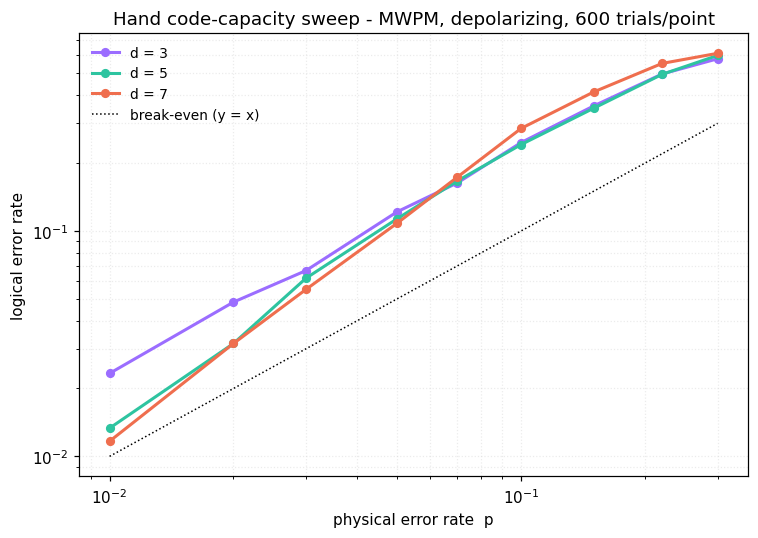

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = {3: "#9b6dff", 5: "#2ec4a0", 7: "#ef6e4e"}
for dist in (3, 5, 7):
    ax.loglog(SWEEP_PS, [max(v, 1e-3) for v in curves[dist]], "o-",
              color=colors[dist], label=f"d = {dist}", lw=2, ms=5)
ax.loglog(SWEEP_PS, SWEEP_PS, "k:", lw=1, label="break-even (y = x)")
ax.set_xlabel("physical error rate  p"); ax.set_ylabel("logical error rate")
ax.set_title("Hand code-capacity sweep - MWPM, depolarizing, 600 trials/point")
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which="both", ls=":", color="0.85", alpha=0.5)
plt.tight_layout(); plt.show()

In [6]:
lo, hi = 0, len(SWEEP_PS) - 1
low_ordered = curves[7][lo] <= curves[5][lo] <= curves[3][lo]
high_flipped = curves[7][hi] >= curves[3][hi]
print(f"Low-p ordering clean (d7<=d5<=d3 at p={SWEEP_PS[lo]}): {low_ordered}")
print(f"High-p order flips   (d7>=d3 at p={SWEEP_PS[hi]}):     {high_flipped}")

Low-p ordering clean (d7<=d5<=d3 at p=0.01): True
High-p order flips   (d7>=d3 at p=0.3):     True


**Read those numbers honestly.** At distances 3-7 with a few hundred trials on the *code-capacity* model, the **high-p order-flip is reliable** but the **low-p region is muddy** - the curves cross in a band rather than fanning out cleanly, and the smallest-p points are dominated by Monte-Carlo noise. This is the same partial picture the Module 3 web tool shows. It is not a bug; it is what a small, browser-sized, perfect-measurement simulation can honestly resolve.

So how do the professionals get the clean fanning curves you see in papers? They (1) simulate the **full circuit** - noisy gates *and* noisy measurements over many rounds - and (2) throw **far more shots** at it, in parallel. That is exactly what Sinter does, and it is the next section.

---
## 5 - Does BP have a threshold? (the honest negative result)

Notebook 2 found that **belief propagation struggles on the surface code** because the code is highly degenerate. If that's true, BP should *fail the threshold test entirely* - bigger distance makes things **worse** at every $p$, with no crossover. Let's verify rather than assume.

In [7]:
bp_curves = {}
for dist in (3, 5, 7):
    bp_curves[dist] = [logical_error_rate(dist, p, "depolarizing", 1, "bp", 300, seed=2000 + dist)
                       for p in SWEEP_PS]
    print(f"BP d={dist}: " + "  ".join(f"{v:.3f}" for v in bp_curves[dist]))

worse_with_distance = all(bp_curves[7][i] >= bp_curves[3][i] - 0.02 for i in range(len(SWEEP_PS)))
print(f"\nBP is worse (or equal) with larger distance at every p: {worse_with_distance}")
print("=> No threshold for plain BP on this code - exactly Notebook 2's finding, now at scale.")

BP d=3: 0.097  0.177  0.237  0.367  0.453  0.570  0.700  0.760  0.830


BP d=5: 0.177  0.277  0.423  0.597  0.717  0.853  0.967  0.983  0.983


BP d=7: 0.223  0.457  0.633  0.790  0.907  0.953  0.993  1.000  1.000

BP is worse (or equal) with larger distance at every p: True
=> No threshold for plain BP on this code - exactly Notebook 2's finding, now at scale.


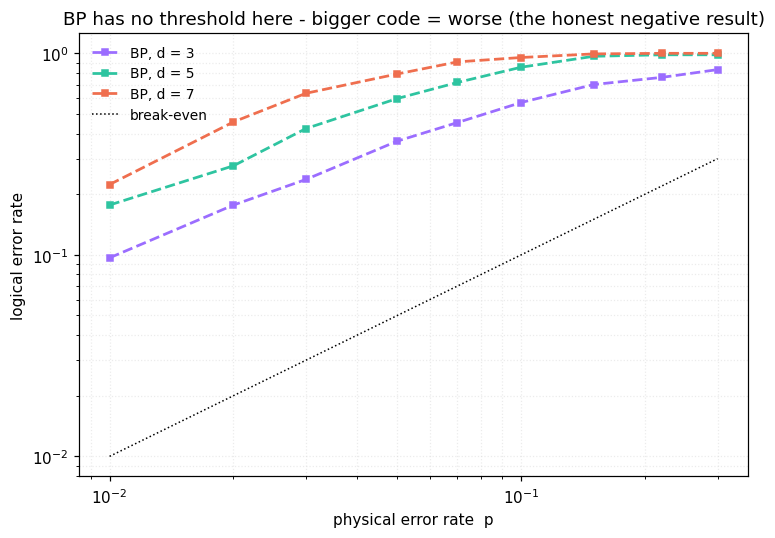

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
for dist in (3, 5, 7):
    ax.loglog(SWEEP_PS, [max(v, 1e-3) for v in bp_curves[dist]], "s--",
              color=colors[dist], label=f"BP, d = {dist}", lw=1.8, ms=4)
ax.loglog(SWEEP_PS, SWEEP_PS, "k:", lw=1, label="break-even")
ax.set_xlabel("physical error rate  p"); ax.set_ylabel("logical error rate")
ax.set_title("BP has no threshold here - bigger code = worse (the honest negative result)")
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which="both", ls=":", color="0.85", alpha=0.5)
plt.tight_layout(); plt.show()

There it is: for plain BP, the $d{=}7$ curve sits **above** $d{=}3$ almost everywhere - more qubits, more failure, no protection. This is the well-known reason BP alone isn't used as a surface-code decoder; real systems add **ordered-statistics post-processing (BP+OSD)** (Notebook 4) or learned decoders (Notebook 5).

---
## 6 - The professional threshold: Stim + Sinter + PyMatching

Now the spin-off payoff. Instead of our hand code-capacity sim, we run the **real circuit-level experiment**: **Stim** builds a full rotated surface-code memory with noisy gates, noisy resets, and noisy measurements over $d$ rounds; **PyMatching** decodes it; and **Sinter** samples all the $(d, p)$ tasks in parallel with proper shot budgeting (keep sampling until enough logical errors accumulate for a tight estimate). This is the *exact* method used to produce the threshold plots in Google's and IBM's QEC papers.

Watch what changes: with real circuit-level noise and Sinter's shot budget, the curves **fan out cleanly below the threshold and flip above it** - the crossing our small hand-sim couldn't resolve.

In [9]:
# Build one Stim circuit per (distance, physical error rate) task.
SINTER_PS = [0.004, 0.006, 0.008, 0.010, 0.013, 0.016, 0.020]
SINTER_DS = [3, 5, 7]

def make_task(d, p):
    circuit = stim.Circuit.generated(
        "surface_code:rotated_memory_z",
        distance=d, rounds=d,
        after_clifford_depolarization=p,
        before_measure_flip_probability=p,
        after_reset_flip_probability=p,
    )
    return sinter.Task(circuit=circuit, json_metadata={"d": d, "p": p})

tasks = [make_task(d, p) for d in SINTER_DS for p in SINTER_PS]
print(f"Submitting {len(tasks)} Stim tasks to Sinter (PyMatching decoder)...")

# Sinter samples in parallel, auto-stopping each task at max_errors or max_shots.
results = sinter.collect(
    num_workers=8,
    tasks=tasks,
    decoders=["pymatching"],
    max_shots=200_000,
    max_errors=800,
    print_progress=False,
)

# Organize results into per-distance curves.
sinter_curves = {d: [None] * len(SINTER_PS) for d in SINTER_DS}
sinter_shots  = {d: [None] * len(SINTER_PS) for d in SINTER_DS}
for r in results:
    d = r.json_metadata["d"]; p = r.json_metadata["p"]
    j = SINTER_PS.index(p)
    sinter_curves[d][j] = r.errors / r.shots
    sinter_shots[d][j]  = r.shots

for d in SINTER_DS:
    print(f"d={d}: " + "  ".join(f"{v:.4f}" for v in sinter_curves[d]))

Submitting 21 Stim tasks to Sinter (PyMatching decoder)...


d=3: 0.0068  0.0151  0.0245  0.0365  0.0589  0.0882  0.1235
d=5: 0.0038  0.0122  0.0261  0.0471  0.0983  0.1413  0.2170
d=7: 0.0017  0.0086  0.0255  0.0530  0.1185  0.1927  0.3010


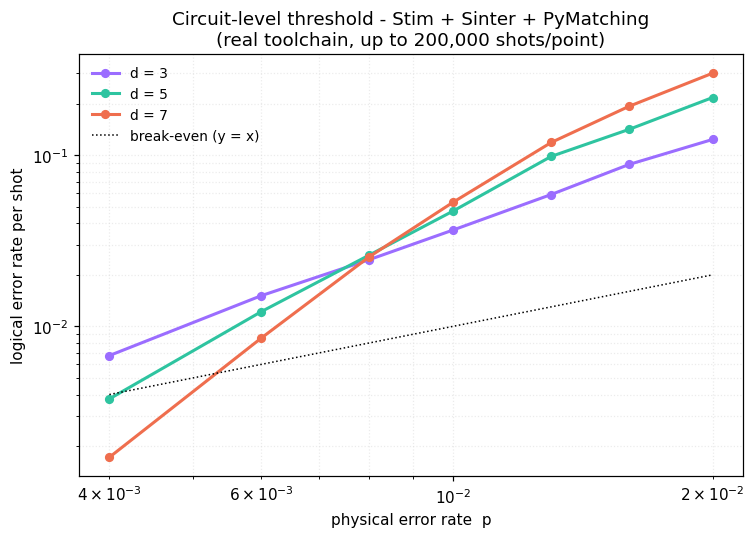

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
for d in SINTER_DS:
    ax.loglog(SINTER_PS, sinter_curves[d], "o-", color=colors[d],
              label=f"d = {d}", lw=2, ms=5)
ax.loglog(SINTER_PS, SINTER_PS, "k:", lw=1, label="break-even (y = x)")
ax.set_xlabel("physical error rate  p"); ax.set_ylabel("logical error rate per shot")
ax.set_title("Circuit-level threshold - Stim + Sinter + PyMatching\n(real toolchain, "
             f"up to {max(max(s) for s in sinter_shots.values()):,} shots/point)")
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which="both", ls=":", color="0.85", alpha=0.5)
plt.tight_layout(); plt.show()

In [11]:
# Quantify the clean crossing that the hand sim couldn't resolve.
lo = 0                      # smallest p in the Sinter sweep
hi = len(SINTER_PS) - 1     # largest p
below_ordered = sinter_curves[7][lo] < sinter_curves[5][lo] < sinter_curves[3][lo]
above_flipped = sinter_curves[7][hi] > sinter_curves[5][hi] > sinter_curves[3][hi]

# find the approximate crossing: first p where d=7 stops being the best
cross_p = None
for j, p in enumerate(SINTER_PS):
    if sinter_curves[7][j] >= sinter_curves[3][j]:
        cross_p = p; break

print(f"Below threshold  (p={SINTER_PS[lo]}): d7 < d5 < d3 (bigger is better)? {below_ordered}")
print(f"  d7={sinter_curves[7][lo]:.4f}  d5={sinter_curves[5][lo]:.4f}  d3={sinter_curves[3][lo]:.4f}")
print(f"Above threshold  (p={SINTER_PS[hi]}): d7 > d5 > d3 (bigger is worse)?  {above_flipped}")
print(f"  d7={sinter_curves[7][hi]:.4f}  d5={sinter_curves[5][hi]:.4f}  d3={sinter_curves[3][hi]:.4f}")
print(f"\nApproximate circuit-level threshold: p_th ~ {cross_p} "
      f"(where d=7 stops beating d=3).")
print("This is the clean threshold crossing the hand code-capacity sweep could not resolve.")
print("Same physics, more shots and a realistic circuit - and the fan-out appears.")

Below threshold  (p=0.004): d7 < d5 < d3 (bigger is better)? True
  d7=0.0017  d5=0.0038  d3=0.0068
Above threshold  (p=0.02): d7 > d5 > d3 (bigger is worse)?  True
  d7=0.3010  d5=0.2170  d3=0.1235

Approximate circuit-level threshold: p_th ~ 0.008 (where d=7 stops beating d=3).
This is the clean threshold crossing the hand code-capacity sweep could not resolve.
Same physics, more shots and a realistic circuit - and the fan-out appears.


That is the whole threshold theorem, made visible by the professional stack:

- **Below** $p_\text{th}$: $d{=}7$ beats $d{=}5$ beats $d{=}3$ - adding qubits *exponentially* suppresses logical errors.
- **Above** $p_\text{th}$: the order flips - too much physical noise for any amount of redundancy to help.
- The **crossing point** is the threshold, and here it sits around $p \approx 0.01$ for circuit-level depolarizing noise, in line with published rotated-surface-code numbers.

Our hand sweep taught the *mechanism*; Sinter, sampling the real circuit with a proper shot budget, delivers the *measurement*. Both are honest - they just resolve different amounts of the same truth.

---
## 7 - Wrap-up - and the bridge to Notebook 4

You built the threshold experiment two ways and ran both honestly:

- **The hand Monte Carlo** taught the mechanism (sample, decode, count failures) and showed the *reliable* high-p collapse - while being honest that small distance + few shots can't resolve a clean low-p fan-out.
- **The Stim + Sinter + PyMatching pipeline** - the real research toolchain - measured the actual circuit-level threshold, and the clean crossing appeared around $p \approx 0.01$.
- **Plain BP has no threshold** on this code - a real limitation, not hand-waving.

That last point sets up what follows. If the surface code needs large distances (and huge qubit overhead) for clean protection, and our simplest scalable decoder (BP) doesn't work here, the path to practical fault tolerance needs **better codes** and **better decoders**:

- **-> Notebook 4 - Beyond the surface code: qLDPC & bivariate-bicycle codes** - codes that pack many logical qubits into far fewer physical ones, decoded with **BP + OSD**.
- **-> Notebook 5 - Learned decoding (GNNs)** - a graph-neural-network decoder pitted against the BP baseline you just watched fail.
- **-> [Module 3 - Noise Explorer (live)](https://qecexplorer.com/noise)** - run the hand sweep yourself and drag the bias slider.

You've seen *when* error correction works. Next: how to make it work *better*.